In [7]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")


In [8]:
censo_viv_path = "../data/raw/viviendas_censo2024.parquet"
df_censo_viv = pl.read_parquet(censo_viv_path).filter(pl.col("cant_per") > 0)
display(df_censo_viv.head().to_pandas())


,id_vivienda,region,provincia,comuna,comuna_bajo_umbral,area,tipo_operativo,cant_hog,cant_per,p2_tipo_vivienda,...,p5_num_dormitorios,p6_fuente_agua,p7_distrib_agua,p8_serv_hig,p9_fuente_elect,p10_basura,p11a_num_personas,p11b_comparte_gasto,p11c_num_hogar,indice_hacinamiento
0,1,5,58,5802,2,1,2,1,4,1,...,2,1,1,1,1,1,4,1.0,NaN,1
1,2,4,43,4303,2,2,2,1,3,1,...,2,1,1,3,1,1,3,1.0,NaN,1
2,3,11,112,11202,1,1,2,1,3,1,...,3,1,1,1,1,1,3,1.0,NaN,1
3,4,1,11,1101,2,1,2,1,3,3,...,2,1,1,1,1,1,3,1.0,NaN,1
4,5,8,83,8301,2,1,2,1,1,1,...,1,1,1,1,1,1,1,NaN,NaN,1


In [15]:
casen_path = "../data/raw/casen_2024.dta"
Col_variables = ['region', 'expr', 'v15', 'ind_hacina', 'v3', 'pobreza_multi']
df_casen = pd.read_stata(casen_path, columns=Col_variables).dropna(subset=['region', 'v15'])
display(df_casen.head())


,region,expr,v15,ind_hacina,v3,pobreza_multi
0,Región Metropolitana de Santiago,264,"4. No, la recibió de herencia o traspaso gratuito","Sin hacinamiento (menos de 2,5 personas por do...",2. Aceptable,Hogar fuera de pobreza multidimensional
1,Región Metropolitana de Santiago,264,"4. No, la recibió de herencia o traspaso gratuito","Sin hacinamiento (menos de 2,5 personas por do...",2. Aceptable,Hogar fuera de pobreza multidimensional
7,Región Metropolitana de Santiago,266,"4. No, la recibió de herencia o traspaso gratuito","Sin hacinamiento (menos de 2,5 personas por do...",2. Aceptable,Hogar fuera de pobreza multidimensional
8,Región Metropolitana de Santiago,266,"4. No, la recibió de herencia o traspaso gratuito","Sin hacinamiento (menos de 2,5 personas por do...",2. Aceptable,Hogar fuera de pobreza multidimensional
9,Región Metropolitana de Santiago,266,"4. No, la recibió de herencia o traspaso gratuito","Sin hacinamiento (menos de 2,5 personas por do...",2. Aceptable,Hogar fuera de pobreza multidimensional


In [10]:
# Calculamos promedios del censo
censo_reg = df_censo_viv.group_by("region").agg([
    pl.col("indice_hacinamiento").mean().alias("Hacinamiento_Medio"),
    pl.col("cant_per").mean().alias("Personas_por_hogar_medio")
]).to_pandas()

# Calculamos proporciones en Casen
casen_reg = df_casen.groupby("region", observed=False).apply(lambda x: pd.Series({
    "%_Con_Subsidio": (x["v15"].astype(str).str.contains("Sí|Si", case=False, na=False) * x["expr"]).sum() / x["expr"].sum() * 100,
    "%_Pobres_Multi": (x["pobreza_multi"].astype(str).str.contains("Pobre|pobre", case=False, na=False) * x["expr"]).sum() / x["expr"].sum() * 100
})).reset_index()

# Fusionamos
df_plot1 = pd.merge(casen_reg, censo_reg, on="region", how="inner")
df_plot1.set_index("region", inplace=True)

# Normalizar columnas para el mapa de calor multivariado (escala de 0 a 1 min-max) para que sean comparables
df_plot1_norm = (df_plot1 - df_plot1.min()) / (df_plot1.max() - df_plot1.min())

print("Visualizando los datos agregados y fusionados a nivel Regional:")
display(df_plot1.round())


Visualizando los datos agregados y fusionados a nivel Regional:


,%_Con_Subsidio,%_Pobres_Multi,Hacinamiento_Medio,Personas_por_hogar_medio
region,,,,


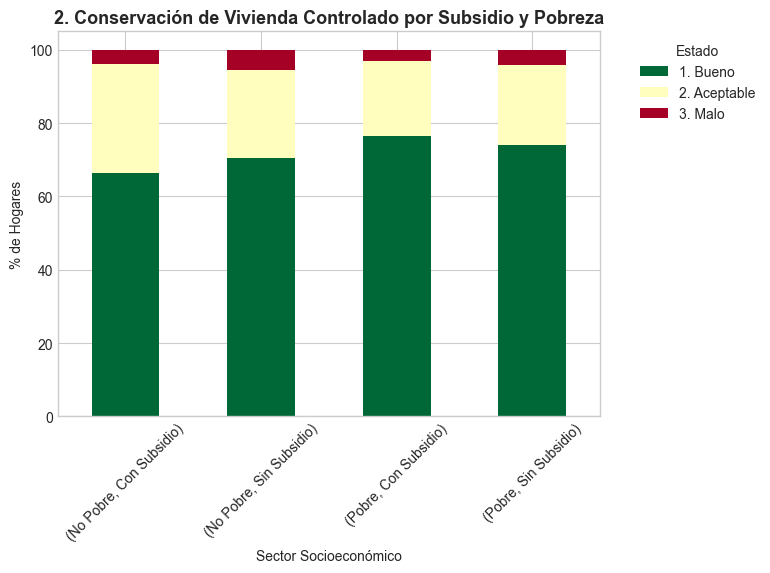

In [11]:
t_sub = np.where(df_casen['v15'].astype(str).str.contains("Sí|Si", case=False, na=False), 'Con Subsidio', 'Sin Subsidio')
t_pob = np.where(df_casen['pobreza_multi'].astype(str).str.contains("Pobre|pobre", case=False, na=False), 'Pobre', 'No Pobre')

ct_g2 = pd.crosstab([t_pob, t_sub], df_casen['v3'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(7, 5))
ct_g2.plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn_r')
ax.set_title("2. Conservación de Vivienda Controlado por Subsidio y Pobreza", fontsize=13, fontweight='bold')
ax.set_ylabel("% de Hogares")
ax.set_xlabel("Sector Socioeconómico")
ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()


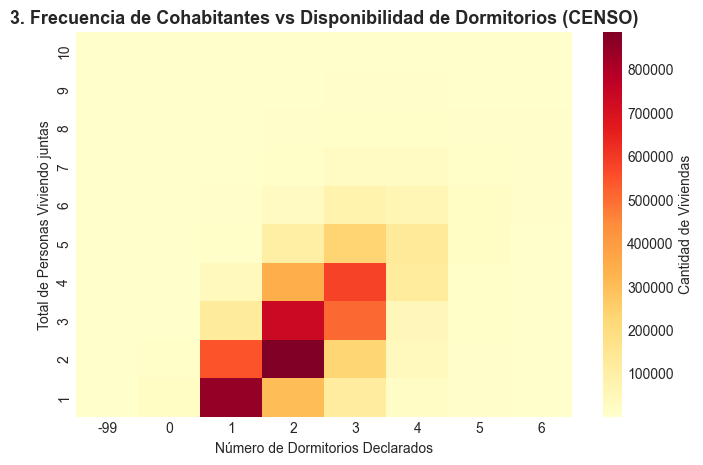

In [12]:
df_plot3 = df_censo_viv.filter((pl.col("p5_num_dormitorios") <= 6) & (pl.col("cant_per") <= 10)).select(["p5_num_dormitorios", "cant_per"]).to_pandas()

# Matriz de frecuencias
ct_g3 = pd.crosstab(df_plot3['cant_per'], df_plot3['p5_num_dormitorios'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(ct_g3, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Cantidad de Viviendas'})
ax.invert_yaxis() # Para que el 1 empiece abajo y 10 arriba
ax.set_title("3. Frecuencia de Cohabitantes vs Disponibilidad de Dormitorios (CENSO)", fontsize=13, fontweight='bold')
ax.set_xlabel("Número de Dormitorios Declarados")
ax.set_ylabel("Total de Personas Viviendo juntas")
plt.show()


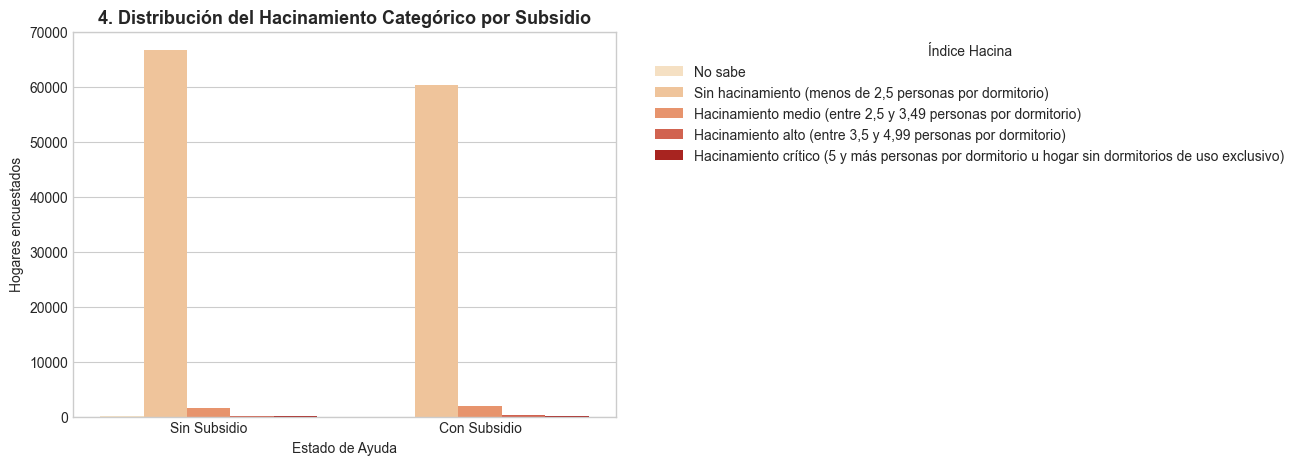

In [13]:
temp_g4 = pd.DataFrame({
    'Subsidio': np.where(df_casen['v15'].astype(str).str.contains("Sí|Si", case=False, na=False), 'Con Subsidio', 'Sin Subsidio'),
    'Hacinamiento': df_casen['ind_hacina']
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=temp_g4, x='Subsidio', hue='Hacinamiento', ax=ax, palette='OrRd')
ax.set_title("4. Distribución del Hacinamiento Categórico por Subsidio", fontsize=13, fontweight='bold')
ax.set_xlabel("Estado de Ayuda")
ax.set_ylabel("Hogares encuestados")
ax.legend(title="Índice Hacina", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
